# Weather-Based Tennis Play Prediction Using Machine Learning Algorithms

**ID3 Algorithm**

A well-known decision tree approach for machine learning is the Iterative Dichotomiser 3 (ID3) algorithm. By choosing the best characteristic at each node to partition the data depending on information gain, it recursively constructs a tree. The goal is to make the final subsets as homogeneous as possible. By choosing features that offer the greatest reduction in entropy or uncertainty, ID3 iteratively grows the tree. The procedure keeps going until a halting requirement is satisfied, like a minimum subset size or a maximum tree depth. Although ID3 is a fundamental method, other iterations such as C4.5 and CART have address.

$$\text{How ID3 Works :}$$

The ID3 algorithm is specifically designed for building decision trees from a given dataset. Its primary objective is to construct a tree that best explains the relationship between attributes in the data and their corresponding class labels.

**1. Selecting the Best Attribute**

ID3 employs the concept of entropy and information gain to determine the attribute that best separates the data. Entropy measures the impurity or randomness in the dataset.
The algorithm calculates the entropy of each attribute and selects the one that results in the most significant information gain when used for splitting the data.

**2. Creating Tree Nodes**

The chosen attribute is used to split the dataset into subsets based on its distinct values.
For each subset, ID3 recurses to find the next best attribute to further partition the data, forming branches and new nodes accordingly.

**3. Stopping Criteria**

The recursion continues until one of the stopping criteria is met, such as when all instances in a branch belong to the same class or when all attributes have been used for splitting.

**4. Handling Missing Values**

ID3 can handle missing attribute values by employing various strategies like attribute mean/mode substitution or using majority class values.

**5. Tree Pruning**

Pruning is a technique to prevent overfitting. While not directly included in ID3, post-processing techniques or variations like C4.5 incorporate pruning to improve the tree's generalization.


$$\text{Limitations :}$$

**Overfitting**:

ID3 tends to create complex trees that may overfit the training data, impacting generalization to unseen instances.

**Sensitive to Noise:**

Noise or outliers in the data can lead to the creation of non-optimal or incorrect splits.

**Binary Trees Only:**

ID3 constructs binary trees, limiting its ability to represent more complex relationships present in the data directly.

X = Weather (single attribute(1D))

Y = Class {Yes, No}

Total samples N = 8

In [ ]:
# X (Weather feature)
X = [
    ['Sunny'],
    ['Sunny'],
    ['Overcast'],
    ['Rain'],
    ['Rain'],
    ['Rain'],
    ['Overcast'],
    ['Sunny']
]

# y (Target: Play Tennis)
y = [
    'No',
    'No',
    'Yes',
    'Yes',
    'Yes',
    'No',
    'Yes',
    'No'
]
n=len(y)
print(f"Total samples (N): {n}")

print("X (Weather):", X)
print("y (Play Tennis):", y)



Total samples (N): 8
X (Weather): [['Sunny'], ['Sunny'], ['Overcast'], ['Rain'], ['Rain'], ['Rain'], ['Overcast'], ['Sunny']]
y (Play Tennis): ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No']


**STEP 1 — Count Class Labels**

The dataset contains two class labels: Yes and No.

Mathematical count:
$$
\text{Yes} = 4, \quad \text{No} = 4
$$

Total number of samples:
$$
|S| = 8
$$

$S$ denotes the entire dataset (training set) at the current node.

$|S|$ represents the total number of instances in the dataset $S$.

In [ ]:
yes=y.count('Yes')
no=y.count('No')
print("Count of 'Yes':", yes)
print("Count of 'No':", no)
print("Total number of samples (|S|):", n)

Count of 'Yes': 4
Count of 'No': 4
Total number of samples (|S|): 8



**STEP 2 — Entropy of Dataset (Root Node)**

For a dataset $S$ with classes $c_1, c_2, \dots, c_k$:
$$
\text{Entropy}(S)
= - \sum_{i=1}^{k} p_i \log_2(p_i)
$$

where:
$$
p_i = \frac{\text{number of instances in class } i}{\text{total number of instances}}
$$
and
$k$ is the number of distinct class labels.

Example:
$$
k = 2 \quad (\text{Yes, No})
$$


Apply the formula:

Probability of class Yes:
$$
p(\text{Yes}) = \frac{4}{8} = 0.5
$$

Probability of class No:
$$
p(\text{No}) = \frac{4}{8} = 0.5
$$

Substitute into entropy formula:
$$
\text{Entropy}(S)
= -0.5 \log_2(0.5) - 0.5 \log_2(0.5)
$$

Final entropy value:
$$
\text{Entropy}(S) = 1.0
$$


In [ ]:
import math

p_yes = yes/n
p_no = no/n
print(f"Probability of 'Yes': {p_yes}")
print(f"Probability of 'No': {p_no}")

entropy_S = -p_yes*math.log2(p_yes) - p_no*math.log2(p_no)
print("Entropy of S:", entropy_S)


Probability of 'Yes': 0.5
Probability of 'No': 0.5
Entropy of S: 1.0


**STEP 3 — Split by Single Attribute**

For a subset $S_v$ corresponding to an attribute value $v$:
$$
\text{Entropy}(S_v)
= - \sum_{i=1}^{k} p_{i|v} \log_2(p_{i|v})
$$

$p_i$ is the probability of class $c_i$ in dataset $S$.
$$
p_i =
\frac{\text{number of instances in class } c_i}{|S|}
$$
$c_i$ denotes the $i$-th class label.

Example:
$$
c_1 = \text{Yes}, \quad c_2 = \text{No}
$$


The attribute Weather has the following possible values:
$$
\{\text{Sunny},\; \text{Overcast},\; \text{Rain}\}
$$


**Subset 1: Weather = Sunny**

Class distribution:
$$
\text{Yes} = 0, \quad \text{No} = 3
$$

Entropy of the Sunny subset:
$$
\text{Entropy}(\text{Sunny})
= - 1 \log_2(1)
= 0
$$


**Subset 2: Weather = Overcast**

Class distribution:
$$
\text{Yes} = 2, \quad \text{No} = 0
$$

Entropy of the Overcast subset:
$$
\text{Entropy}(\text{Overcast}) = 0
$$


**Subset 3: Weather = Rain**

Class distribution:
$$
\text{Yes} = 2, \quad \text{No} = 1
$$

Entropy of the Rain subset:
$$
\text{Entropy}(\text{Rain})
= -\frac{2}{3}\log_2\left(\frac{2}{3}\right)
- \frac{1}{3}\log_2\left(\frac{1}{3}\right)
\approx 0.918
$$


In [ ]:
s_yes = 0
s_no = 0
o_yes = 0
o_no = 0
r_yes = 0
r_no = 0

for i in range(len(X)):
    weather = X[i][0] # X is a list of lists, so X[i][0] gets the weather string
    play_tennis = y[i]

    if weather == 'Sunny':
        if play_tennis == 'Yes':
            s_yes += 1
        else:
            s_no += 1
    elif weather == 'Overcast':
        if play_tennis == 'Yes':
            o_yes += 1
        else:
            o_no += 1
    elif weather == 'Rain':
        if play_tennis == 'Yes':
            r_yes += 1
        else:
            r_no += 1

print("Class distribution for Weather = Sunny:")
print(f"Yes: {s_yes}")
print(f"No: {s_no}")

print("Class distribution for Weather = Overcast:")
print(f"Yes: {o_yes}")
print(f"No: {o_no}")

print("Class distribution for Weather = Rain:")
print(f"Yes: {r_yes}")
print(f"No: {r_no}")

Class distribution for Weather = Sunny:
Yes: 0
No: 3
Class distribution for Weather = Overcast:
Yes: 2
No: 0
Class distribution for Weather = Rain:
Yes: 2
No: 1


In [ ]:
def entropy(yes, no):
    total = yes + no
    if yes == 0 or no == 0:
        return 0
    p_yes = yes / total
    p_no = no / total
    return -p_yes*math.log2(p_yes) - p_no*math.log2(p_no)

sunny_entropy = entropy(s_yes, s_no)
print("Sunny:",sunny_entropy)

overcast_entropy = entropy(o_yes, o_no)
print("Overcast:",overcast_entropy)

rain_entropy = entropy(r_yes, r_no)
print("Rain:",rain_entropy)


Sunny: 0
Overcast: 0
Rain: 0.9182958340544896


**STEP 4 — Weighted Entropy After Split**




$A$ denotes the attribute (feature) being evaluated for splitting.

Example:
$$
A = \text{Weather}
$$


$\text{Values}(A)$ is the set of all possible values of attribute $A$.

Example:
$$
\text{Values}(\text{Weather})
= \{\text{Sunny}, \text{Overcast}, \text{Rain}\}
$$



$v$ represents one specific value of attribute $A$.

Example:
$$
v = \text{Sunny}
$$


The weighted entropy after splitting the dataset $S$ on an Attribute $A$

$S_v$ is the subset of dataset $S$ where attribute $A$ takes value $v$.

$$
S_v = \{ x \in S \mid A(x) = v \}
$$


Formula:

$$
\text{Entropy}(S, A)
= \sum_{v \in \text{Values}(A)}
\frac{|S_v|}{|S|}
\;\text{Entropy}(S_v)
$$



Apply to the Weather attribute:

Total number of instances:
$$
|S| = 8
$$

Subset sizes and entropies:
$$
|S_{\text{Sunny}}| = 3, \quad \text{Entropy}(\text{Sunny}) = 0
$$

$$
|S_{\text{Overcast}}| = 2, \quad \text{Entropy}(\text{Overcast}) = 0
$$

$$
|S_{\text{Rain}}| = 3, \quad \text{Entropy}(\text{Rain}) = 0.918
$$


Substitute into the formula:
$$
\text{Entropy}_{\text{after}}
=
\frac{3}{8}(0)
+
\frac{2}{8}(0)
+
\frac{3}{8}(0.918)
$$


Final result:
$$
\text{Entropy}_{\text{after}} = 0.344
$$


In [ ]:
s_sunny_total = X.count(['Sunny'])
s_overcast_total = X.count(['Overcast'])
s_rain_total = X.count(['Rain'])

print("subset size of Sunny:", s_sunny_total)
print("subset size of Overcast:", s_overcast_total)
print("subset size of Rain:", s_rain_total)

subset size of Sunny: 3
subset size of Overcast: 2
subset size of Rain: 3


In [ ]:
weighted_entropy = (s_sunny_total/n)*sunny_entropy + (s_overcast_total/n)*overcast_entropy + (s_rain_total/n)*rain_entropy
print("Weighted Entropy after split:", weighted_entropy)

Weighted Entropy after split: 0.3443609377704336


**STEP 5 — Information Gain**

Information Gain measures the expected reduction in entropy due to sorting the dataset $S$ on an attribute $A$. It is calculated as:

$$ \text{Gain}(S, A) = \text{Entropy}(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} \text{Entropy}(S_v) $$

This can be simplified as:

$$ \text{Gain}(S, A) = \text{Entropy}(S) - \text{Entropy}(S, A) $$

Where:
- $\text{Entropy}(S)$ is the entropy of the entire dataset (root node).
- $\text{Entropy}(S, A)$ is the weighted average entropy after splitting on attribute $A$.


Apply to the Weather attribute:

Entropy of the dataset $S$:
$$ \text{Entropy}(S) = 1.0 $$

Weighted entropy after splitting on Weather:
$$ \text{Entropy}(S, \text{Weather}) = 0.344 $$

Substitute into the formula:
$$ \text{Gain}(S, \text{Weather}) = 1.0 - 0.344 $$

Final result:
$$ \text{Gain}(S, \text{Weather}) = 0.656 $$

In [ ]:
information_gain_weather = entropy_S - weighted_entropy
print("Information Gain for Weather attribute:", information_gain_weather)

Information Gain for Weather attribute: 0.6556390622295665


### **STEP 8 — Testing with New Data**

Now that we have built our decision tree, let's create some new data to test its predictive capability. We will use the **predict** function to classify these new instances.

In [ ]:
tree = {
    "Sunny": "No",
    "Overcast": "Yes",
    "Rain": "Yes",
    "Rain": "No"
}

In [ ]:
def predict(tree, x):
    return tree.get(x, "Unknown")


In [ ]:
test_data = ["Sunny", "Overcast", "Rain"]

for sample in test_data:
    print(f" If Weather Is {sample}, Then Play Tennis = {predict(tree, sample)}")


 If Weather Is Sunny, Then Play Tennis = No
 If Weather Is Overcast, Then Play Tennis = Yes
 If Weather Is Rain, Then Play Tennis = No


In [ ]:
true_labels = ["Yes", "Yes", "Yes", "Yes", "No"]
predicted_labels = ["No", "Yes", "Yes", "No", "Yes"]

correct = sum(1 for t, p in zip(true_labels, predicted_labels) if t == p)
accuracy = correct / len(true_labels)

print("Accuracy on noisy data:", accuracy)


Accuracy on noisy data: 0.4


**Improve Accuracy By Pruning**

In [ ]:
pruned_tree = "Yes"

In [ ]:
def predict_pruned(tree, x):
    return tree

In [ ]:
validation_data = [[None, label] for label in true_labels]

In [ ]:
def accuracy_pruned(tree, data):
    correct = 0
    for _, y in data:
        if tree == y:
            correct += 1
    return correct / len(data)

acc_after = accuracy_pruned(pruned_tree, validation_data)
print("Accuracy after pruning:", acc_after)


Accuracy after pruning: 0.8


In [ ]:
new_test_data = ["Sunny"]

for sample2 in new_test_data:
    print(f" If Weather Is {sample2}, Then Play Tennis = {predict_pruned(pruned_tree, sample2)}")


 If Weather Is Sunny, Then Play Tennis = Yes


**As Per Pruning Decision Rule**

If the accuracy of the pruned tree is greater than the accuracy of the original tree, then pruning is performed.

$$
\text{If } \text{Accuracy}_{\text{pruned}} > \text{Accuracy}_{\text{original}}
\;
\text{THEN Prune the tree}
$$


Here 0.8>0.4 , So Pruning is accepted.

# **Write Python code to implement the ID3 algorithm and test it on the PlayTennis dataset, verifying the inductive bias of the decision tree learning algorithm.**

In [ ]:
import pandas as pd

file_id = "12vT2xOnxFrKw9fTerc4wpOf3bsDTeU8F"
url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)
print(df.head())


    outlook  temp humidity  windy play
0     sunny   hot     high  False   no
1     sunny   hot     high   True   no
2  overcast   hot     high  False  yes
3     rainy  mild     high  False  yes
4     rainy  cool   normal  False  yes


In [ ]:
print(df.columns)



Index(['outlook', 'temp', 'humidity', 'windy', 'play'], dtype='object')


In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "").str.lower()
print(df.columns)


Index(['outlook', 'temp', 'humidity', 'windy', 'play'], dtype='object')


In [ ]:
X = df.drop("play", axis=1)
y = df["play"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in X.columns:
    X[col] = encoder.fit_transform(X[col])

y = encoder.fit_transform(y)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# ID3-style tree
model = DecisionTreeClassifier(
    criterion="entropy",   # Information Gain
    random_state=42
)

model.fit(X, y)


DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
accuracy = model.score(X, y)
print("Training Accuracy:", accuracy)


Training Accuracy: 1.0


In [ ]:
for feature, importance in zip(X.columns, model.feature_importances_):
    print(f"{feature:12} : {importance:.4f}")

outlook      : 0.3626
temp         : 0.1519
humidity     : 0.2112
windy        : 0.2742


In [ ]:
root_feature = X.columns[model.tree_.feature[0]]
print("Root attribute selected by ID3:", root_feature)


Root attribute selected by ID3: outlook


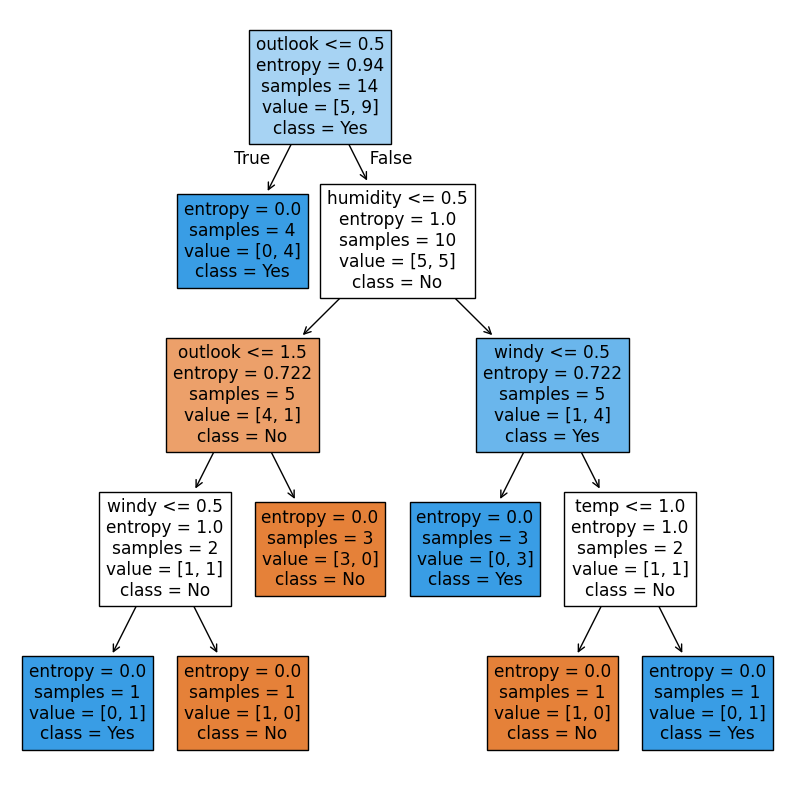

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True
)
plt.show()
